In [11]:
import chess.pgn
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import FancyBboxPatch
import numpy as np

In [2]:
output_folder = r"D:\Chess"
final_csv_path = r"D:\Chess\master_chess_data_2013_full.csv"

In [3]:
# 1. Loop through your 6 files
for month in range(1, 7):
    filename = f"lichess_db_standard_rated_2013-{month:02d}.pgn"
    file_path = os.path.join(output_folder, filename)
    
    if os.path.exists(file_path):
        print(f"🚀 Processing ALL games from {filename}...")
        month_games_list = []
        
        with open(file_path, encoding="utf-8") as pgn:
            # 2. Loop until the end of the file
            while True:
                game = chess.pgn.read_game(pgn)
                if game is None:
                    break  # End of file reached
                
                # Extract headers
                game_data = dict(game.headers)
                game_data["Source_File"] = filename
                month_games_list.append(game_data)
        
        # 3. Convert this month to a DataFrame and append to CSV
        df_month = pd.DataFrame(month_games_list)
        
        # 'a' mode means append; header=False prevents repeating headers
        file_exists = os.path.isfile(final_csv_path)
        df_month.to_csv(final_csv_path, mode='a', index=False, header=not file_exists, encoding="utf-8")
        
        print(f"✅ Finished {filename}. Total games so far: {len(month_games_list)}")
        
        # 4. Clear memory for the next month
        del month_games_list 
        del df_month
    else:
        print(f"Skipping {filename} (not found).")

print(f"\n🎉 All files processed! Your full dataset is at: {final_csv_path}")

🚀 Processing ALL games from lichess_db_standard_rated_2013-01.pgn...


illegal san: 'a5' in r2kQb1r/pbpp3p/1pn1p3/7B/3PP2q/P1N5/1PP2PPP/R3K2R b KQ - 2 13 while parsing <Game at 0x24409bcbad0 ('?' vs. '?', '????.??.??' at '?')>


✅ Finished lichess_db_standard_rated_2013-01.pgn. Total games so far: 121333
🚀 Processing ALL games from lichess_db_standard_rated_2013-02.pgn...


illegal san: 'e4' in r1b1kbr1/pp6/2p1pp2/7p/7N/8/PQP1BPPP/R4RK1 b q - 0 17 while parsing <Game at 0x24409bca7b0 ('?' vs. '?', '????.??.??' at '?')>


✅ Finished lichess_db_standard_rated_2013-02.pgn. Total games so far: 123962
🚀 Processing ALL games from lichess_db_standard_rated_2013-03.pgn...


...

✅ Finished lichess_db_standard_rated_2013-04.pgn. Total games so far: 157872
🚀 Processing ALL games from lichess_db_standard_rated_2013-05.pgn...


illegal san: 'e4' in 2kr1b2/p1np3p/bpp1p1p1/8/4P3/1P1P1P2/P1PRQ1BP/q1K3NR w - - 2 16 while parsing <Game at 0x24409bc9910 ('?' vs. '?', '????.??.??' at '?')>


✅ Finished lichess_db_standard_rated_2013-05.pgn. Total games so far: 179551
🚀 Processing ALL games from lichess_db_standard_rated_2013-06.pgn...


illegal san: 'd4' in 8/1R6/p1p2k2/2P2ppp/PP1P1P2/5K2/5P1P/8 b - - 0 32 while parsing <Game at 0x24409bcb380 ('?' vs. '?', '????.??.??' at '?')>


✅ Finished lichess_db_standard_rated_2013-06.pgn. Total games so far: 224680

🎉 All files processed! Your full dataset is at: D:\Chess\master_chess_data_2013_full.csv


In [4]:
df = pd.read_csv(final_csv_path)
len(df)

C:\Users\salma\AppData\Local\Temp\ipykernel_20368\3882557596.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(final_csv_path)


1932062

In [5]:
df.dtypes

Event               object
Site                object
Date                object
Round               object
White               object
Black               object
Result              object
UTCDate             object
UTCTime             object
WhiteElo            object
BlackElo            object
WhiteRatingDiff    float64
BlackRatingDiff    float64
ECO                 object
Opening             object
TimeControl         object
Termination         object
Source_File         object
BlackTitle          object
WhiteTitle          object
dtype: object

In [6]:
# 1. Convert the columns to numbers first
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')

# 2. Now the comparison will work perfectly
pro_games = df[(df['WhiteElo'] > 2000) | (df['BlackElo'] > 2000)]

# 3. Get the unique names
elite_handles = pd.concat([pro_games['White'], pro_games['Black']]).unique()

print(f"Success! Found {len(elite_handles)} elite handles.")
print(elite_handles)


Success! Found 4299 elite handles.
['moonwalker' 'xiaoqiao' 'cheesedout' ... 'peon58' 'crniGoki'
 'proszachmat']


In [7]:
# 1. Combine White and Black players into one list to find the overall top ratings
white_players = df[['White', 'WhiteElo']].rename(columns={'White': 'Player', 'WhiteElo': 'Elo'})
black_players = df[['Black', 'BlackElo']].rename(columns={'Black': 'Player', 'BlackElo': 'Elo'})

all_players = pd.concat([white_players, black_players])

# 2. Find the maximum rating for each unique player
player_peaks = all_players.groupby('Player')['Elo'].max().reset_index()

# 3. Sort by Elo and take the top 10
top_10 = player_peaks.sort_values(by='Elo', ascending=False).head(10)

print("🏆 The Top 5 Highest Rated Players in your 2013 Data:")
print(top_10)

🏆 The Top 5 Highest Rated Players in your 2013 Data:
             Player     Elo
23093        stoker  2426.0
3913        Gallini  2412.0
9529    TeKakeIsaly  2406.0
12645  brahmsguitar  2403.0
16475        inhume  2399.0
12717         bst01  2390.0
9614        TheKing  2376.0
23452         term9  2354.0
20236        ohyeah  2351.0
9667   Thecheesykid  2350.0


In [8]:
# 1. Get the list of the top 5 usernames from your previous 'top_5' result
top_10_names = top_10['Player'].tolist()

# 2. Filter the pro_games (or df_master) to only include games featuring these 5 players
# We check if the player is either White OR Black
elite_10_games = pro_games[
    (pro_games['White'].isin(top_10_names)) | 
    (pro_games['Black'].isin(top_10_names))
].copy()

print(f"✅ Filter complete! Found {len(elite_10_games)} games involving the Top 10 players.")

# 3. See who is playing whom in this subset
print("\nPreview of Elite 10 Games:")
print(elite_10_games[['White', 'WhiteElo', 'Black', 'BlackElo', 'Result']].head(10))

# 4. Save this specific group for deep analysis
elite_10_games.to_csv(r"D:\Chess\top_5_players_2013.csv", index=False)

✅ Filter complete! Found 7366 games involving the Top 10 players.

Preview of Elite 10 Games:
                   White  WhiteElo              Black  BlackElo Result
7580             TheKing    2363.0        Richard_XII    1390.0    1-0
15331           Hunab_Ku    1712.0            TheKing    2363.0    0-1
15346            TheKing    2364.0     thechessengine    1716.0    1-0
15350            TheKing    2366.0  F1_ALONSO_FERRARI    1813.0    1-0
15353  F1_ALONSO_FERRARI    1812.0            TheKing    2368.0    0-1
15361            TheKing    2370.0           Maniacal    1768.0    1-0
15368             jansom    1535.0            TheKing    2372.0    0-1
15372            TheKing    2372.0       engineabuser    1115.0    1-0
15375       engineabuser    1115.0            TheKing    2372.0    0-1
15407            TheKing    2372.0         Luminosity    1662.0    1-0


📈 Streak graphs saved to: D:\Chess\top_5_streaks.png


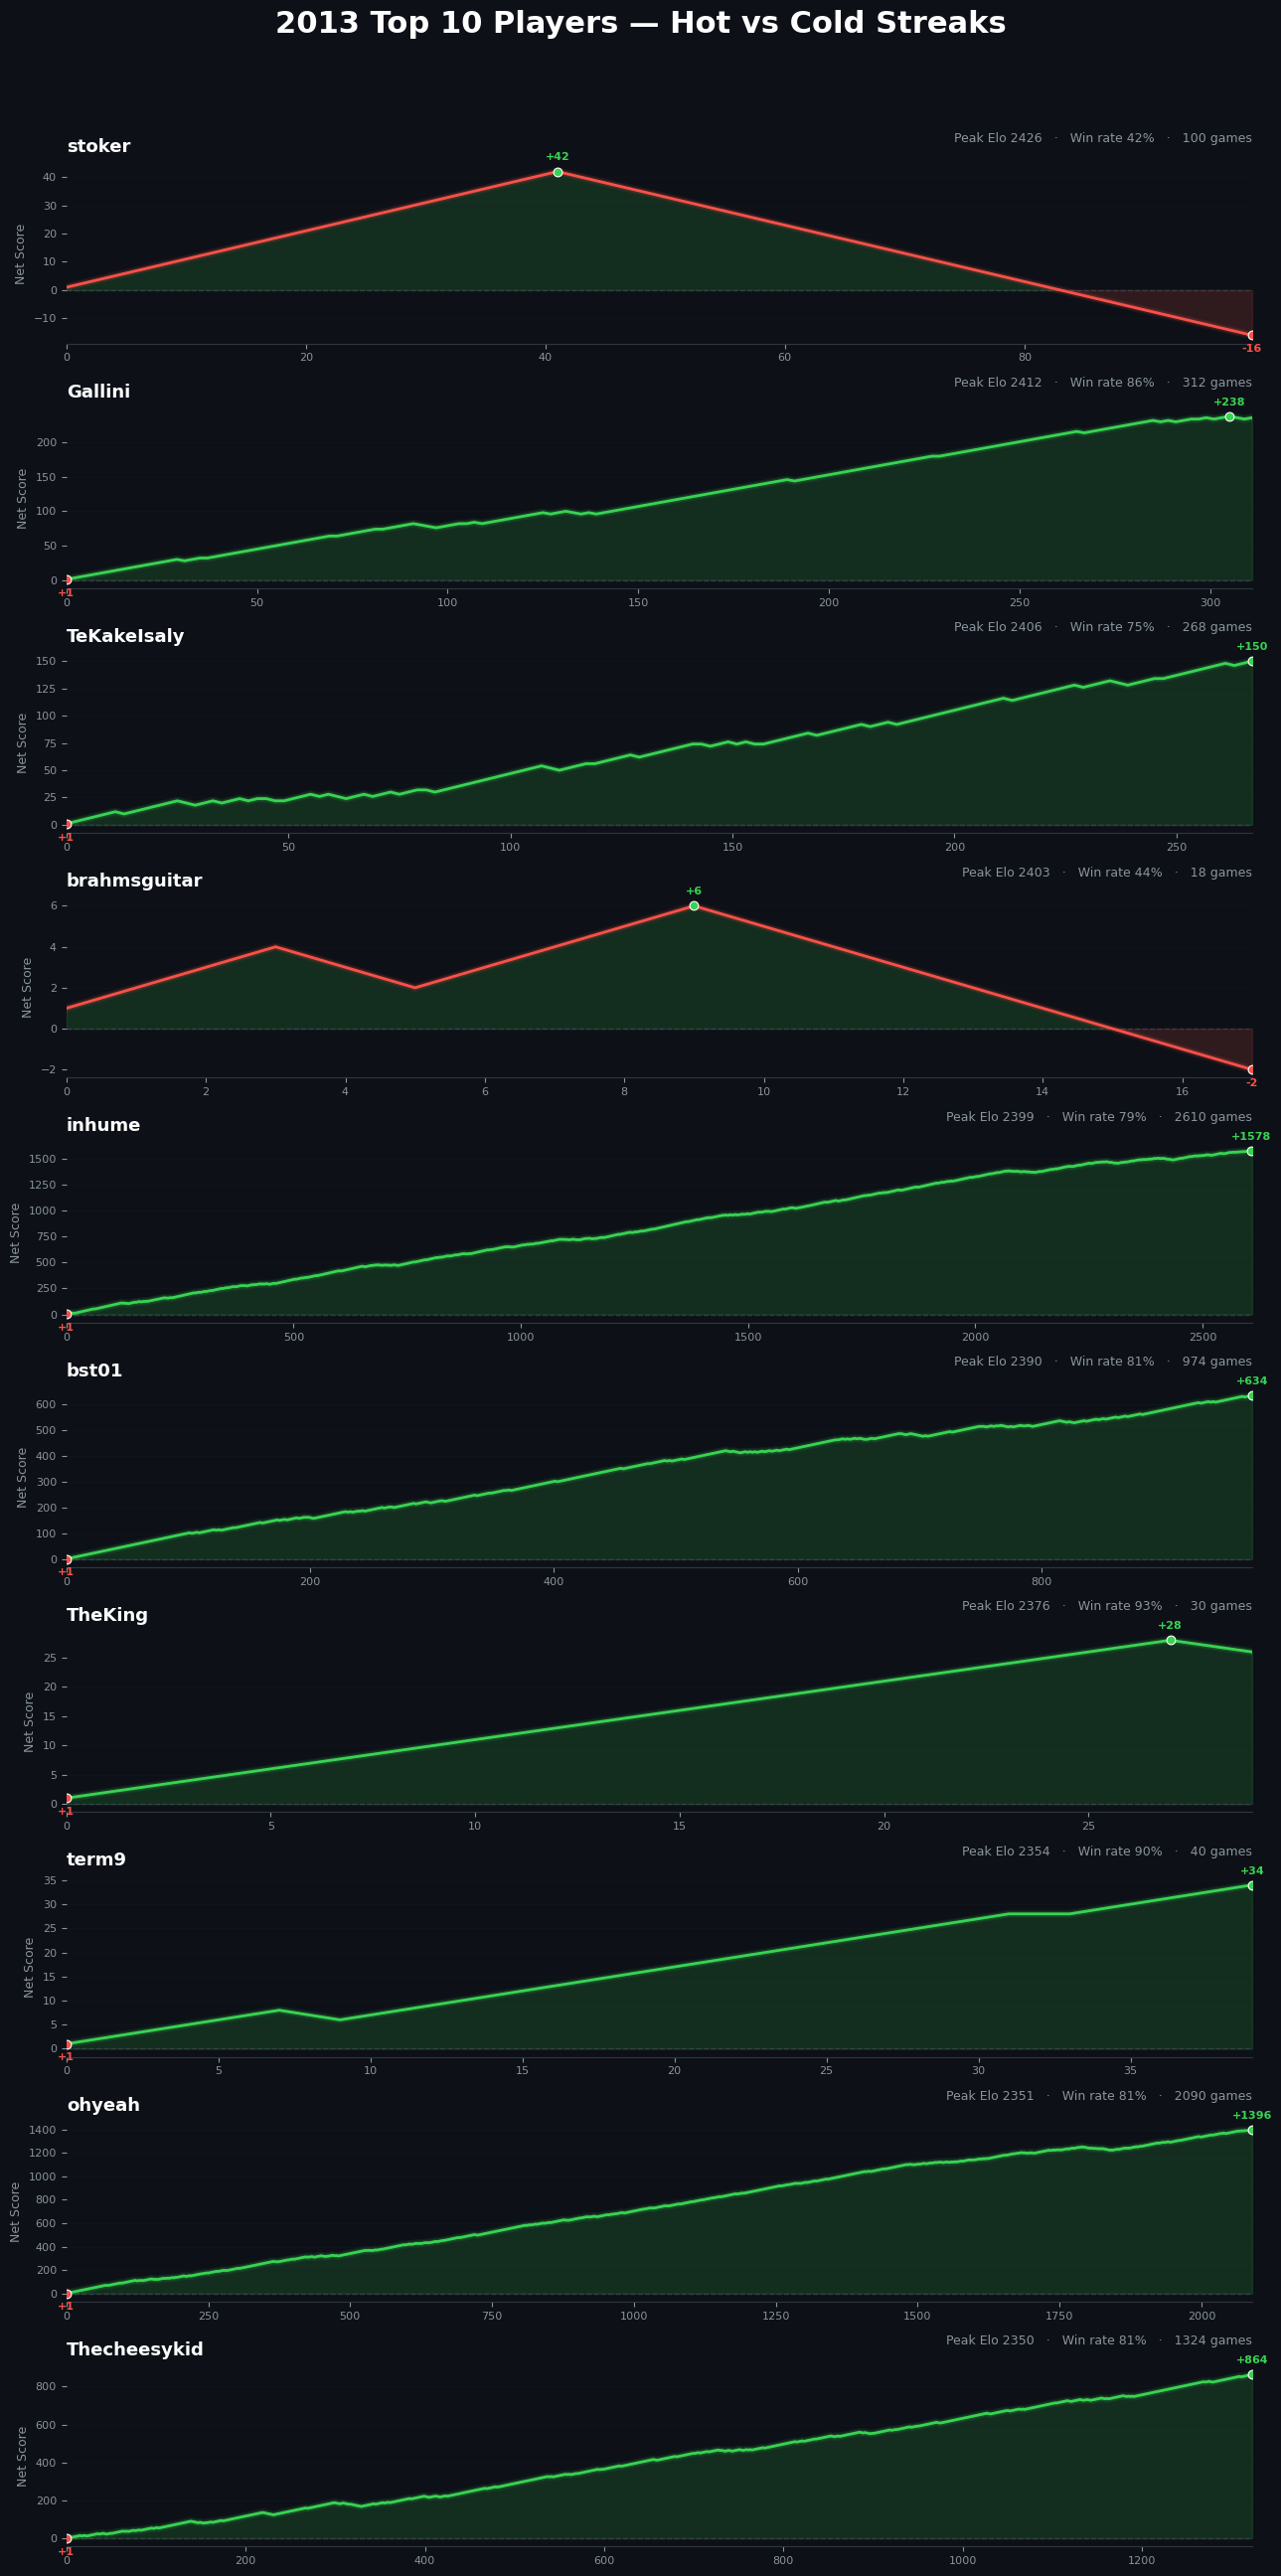

In [13]:

# 3. Sort games chronologically
df['DateTime'] = pd.to_datetime(df['UTCDate'] + ' ' + df['UTCTime'].fillna('00:00:00'))
df = df.sort_values('DateTime')

# --- Style setup ---
plt.style.use('dark_background')
BG = '#0d1117'
GRID = '#21262d'
WIN_COLOR = '#39d353'   # github-green
LOSE_COLOR = '#f85149'  # github-red
ACCENT = '#58a6ff'

fig, axes = plt.subplots(10, 1, figsize=(13, 26), facecolor=BG)
fig.suptitle('2013 Top 10 Players — Hot vs Cold Streaks',
             fontsize=22, fontweight='bold', color='white', y=0.995)
#fig.text(0.5, 0.985, 'Net cumulative win/loss score over game sequence',
          #ha='center', fontsize=11, color='#8b949e')

for i, player in enumerate(top_10_names):
    ax = axes[i]
    ax.set_facecolor(BG)

    p_games = df[(df['White'] == player) | (df['Black'] == player)].copy()

    def get_net_score(row):
        if row['White'] == player:
            if row['Result'] == '1-0': return 1
            if row['Result'] == '0-1': return -1
        else:
            if row['Result'] == '0-1': return 1
            if row['Result'] == '1-0': return -1
        return 0

    p_games['Score'] = p_games.apply(get_net_score, axis=1)
    p_games['Streak_Value'] = p_games['Score'].cumsum()

    x = np.arange(len(p_games))
    y = p_games['Streak_Value'].values
    final_color = WIN_COLOR if y[-1] > 0 else LOSE_COLOR

    # Line with a subtle glow effect (layered alpha strokes)
    for lw, alpha in [(6, 0.08), (4, 0.15), (2, 1.0)]:
        ax.plot(x, y, color=final_color, linewidth=lw, alpha=alpha,
                solid_capstyle='round', zorder=3)

    # Gradient-ish fill: split into win/loss regions
    ax.fill_between(x, y, 0, where=(y >= 0), color=WIN_COLOR, alpha=0.15,
                     interpolate=True, zorder=1)
    ax.fill_between(x, y, 0, where=(y < 0), color=LOSE_COLOR, alpha=0.15,
                     interpolate=True, zorder=1)

    # Zero line
    ax.axhline(0, color='#484f58', linestyle='--', linewidth=1, alpha=0.6, zorder=2)

    # Annotate peak and trough
    peak_idx, trough_idx = np.argmax(y), np.argmin(y)
    ax.scatter([peak_idx], [y[peak_idx]], color=WIN_COLOR, s=40, zorder=4,
               edgecolor='white', linewidth=0.8)
    ax.scatter([trough_idx], [y[trough_idx]], color=LOSE_COLOR, s=40, zorder=4,
               edgecolor='white', linewidth=0.8)
    ax.annotate(f'{y[peak_idx]:+d}', (peak_idx, y[peak_idx]),
                textcoords="offset points", xytext=(0, 8),
                ha='center', fontsize=8, color=WIN_COLOR, fontweight='bold')
    ax.annotate(f'{y[trough_idx]:+d}', (trough_idx, y[trough_idx]),
                textcoords="offset points", xytext=(0, -12),
                ha='center', fontsize=8, color=LOSE_COLOR, fontweight='bold')

    # Title / stats
    peak_elo = int(all_players[all_players['Player'] == player]['Elo'].max())
    win_rate = (p_games['Score'] > 0).mean() * 100
    ax.set_title(f"{player}", fontsize=13, fontweight='bold', color='white', loc='left', pad=8)
    ax.text(1.0, 1.12, f"Peak Elo {peak_elo}   ·   Win rate {win_rate:.0f}%   ·   {len(p_games)} games",
            transform=ax.transAxes, ha='right', fontsize=9, color='#8b949e')

    ax.set_ylabel("Net Score", fontsize=9, color='#8b949e')
    ax.grid(True, axis='y', alpha=0.15, color=GRID)
    ax.grid(False, axis='x')
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#30363d')
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.set_xlim(0, len(p_games) - 1 if len(p_games) > 1 else 1)

plt.tight_layout(rect=[0, 0, 1, 0.97])
save_img_path = r"D:\Chess\top_5_streaks.png"
plt.savefig(save_img_path, bbox_inches='tight', facecolor=BG, dpi=150)
print(f"📈 Streak graphs saved to: {save_img_path}")
plt.show()

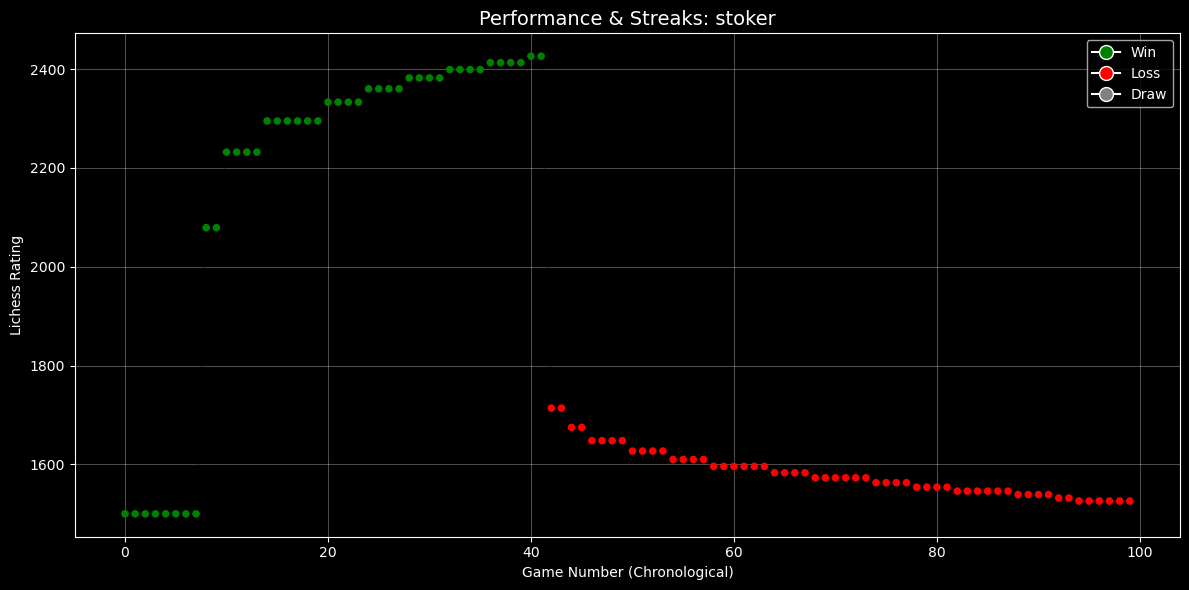

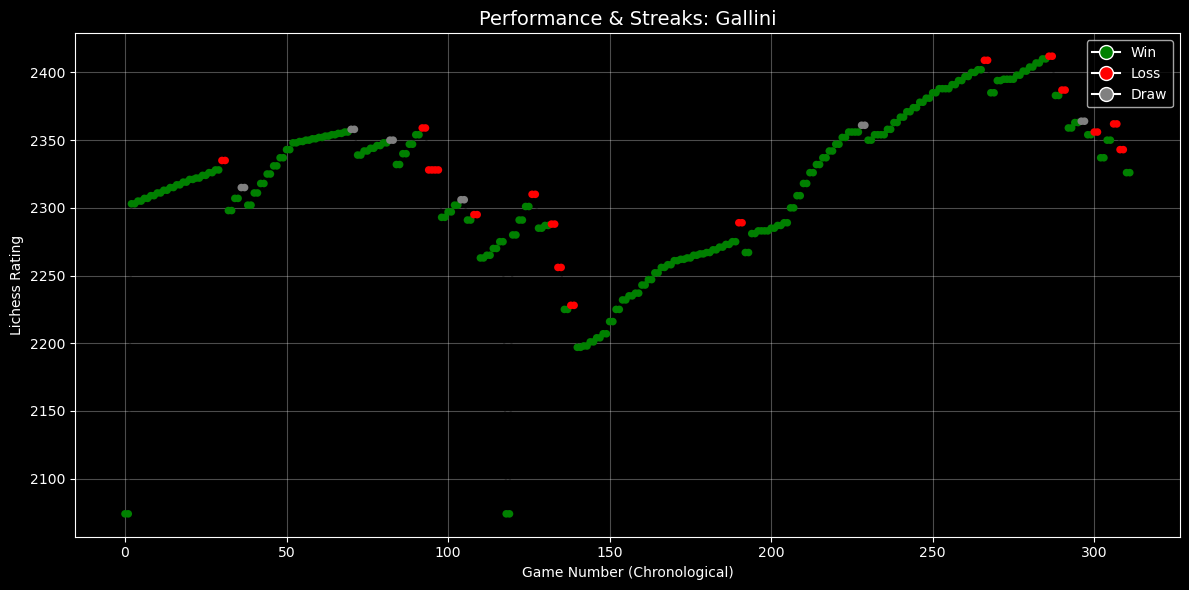

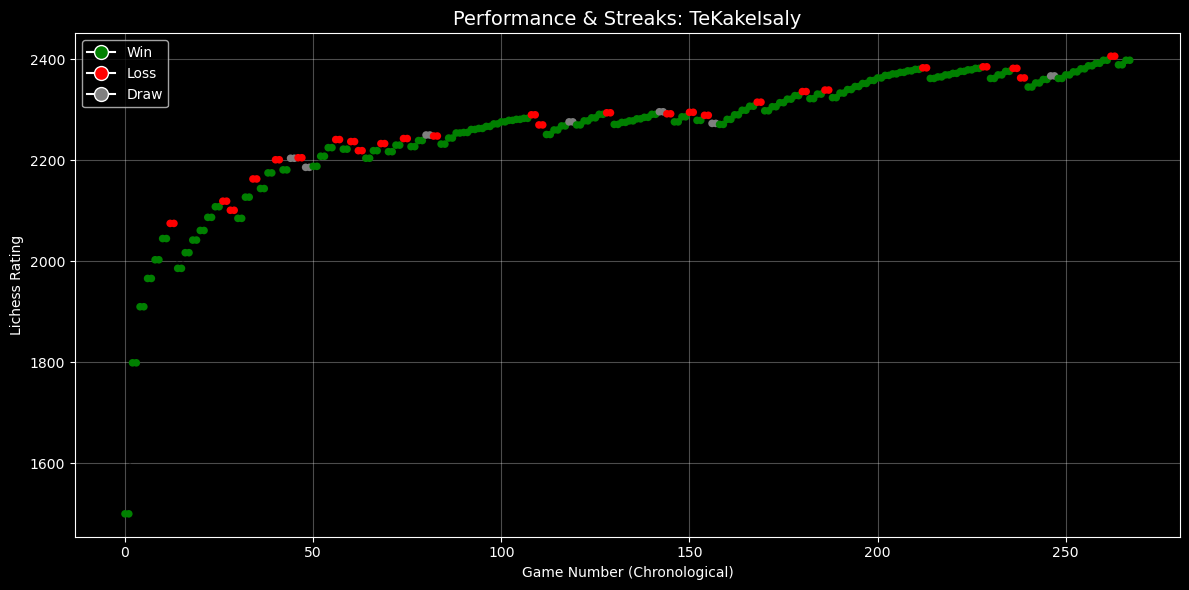

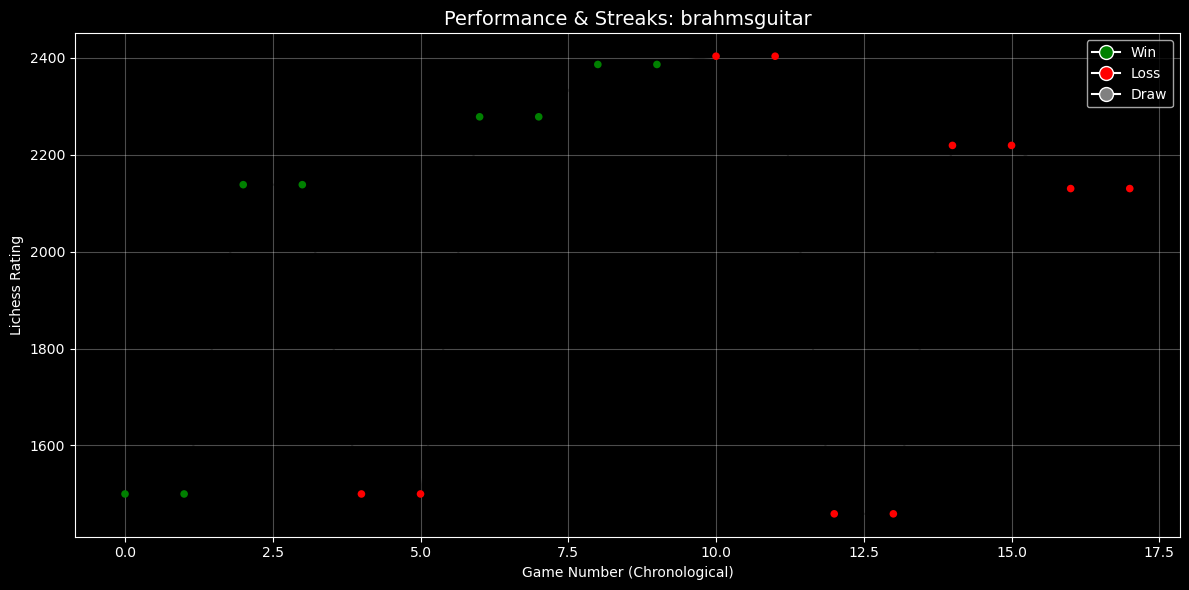

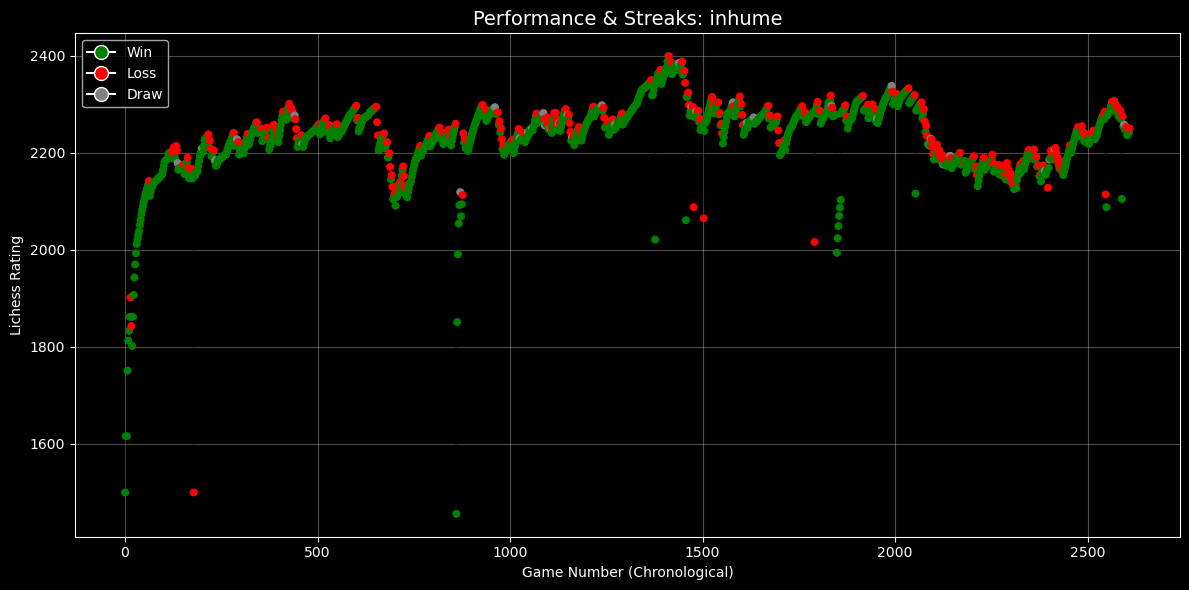

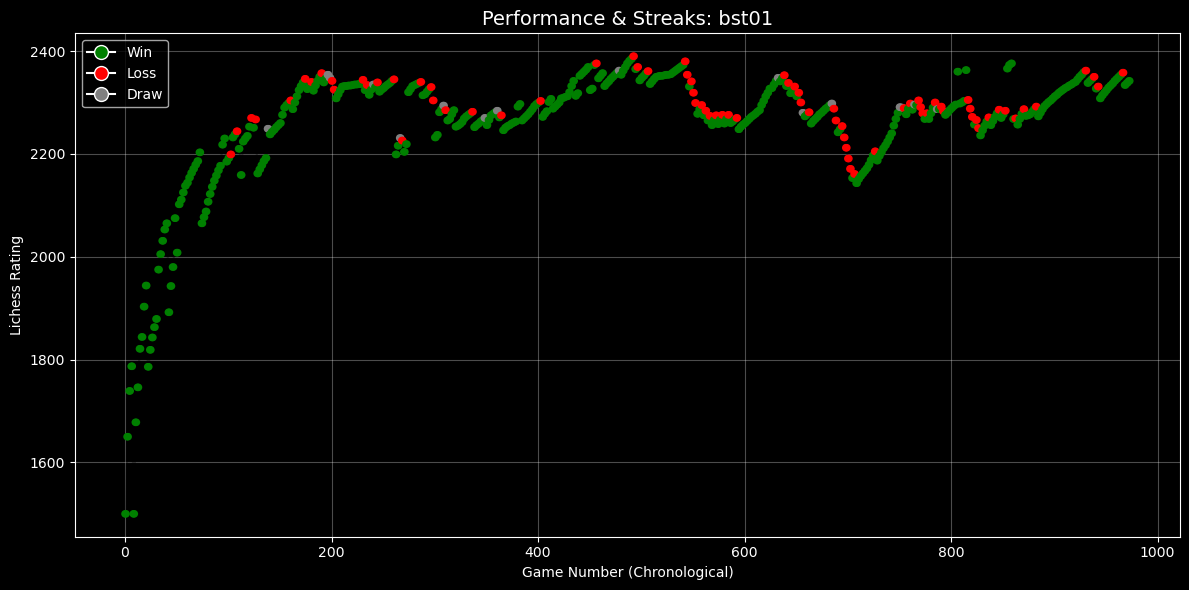

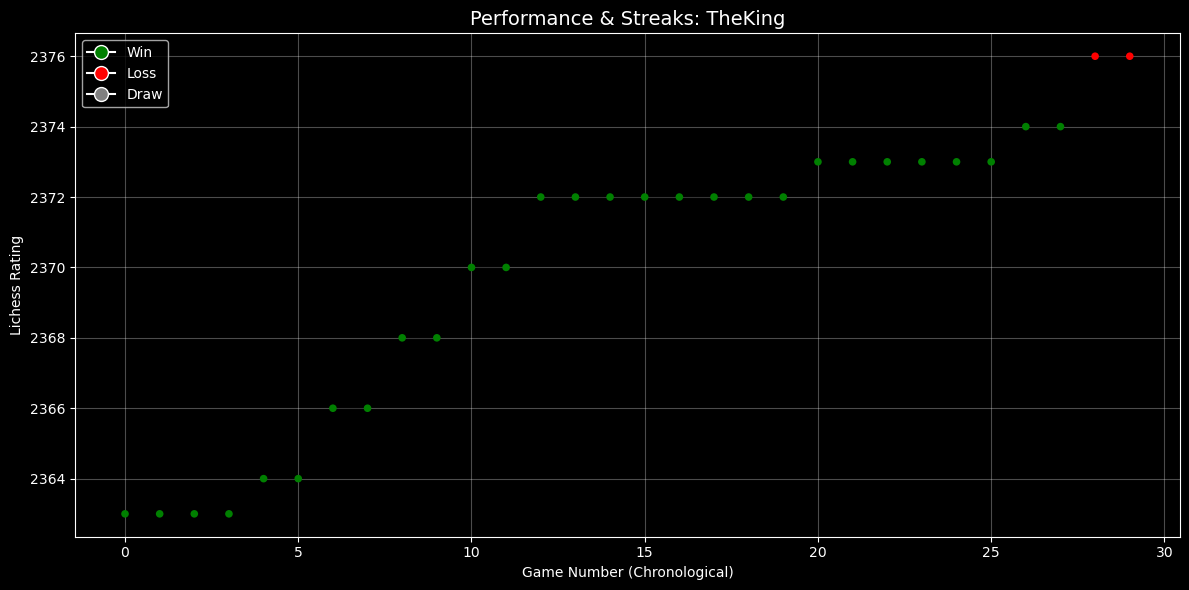

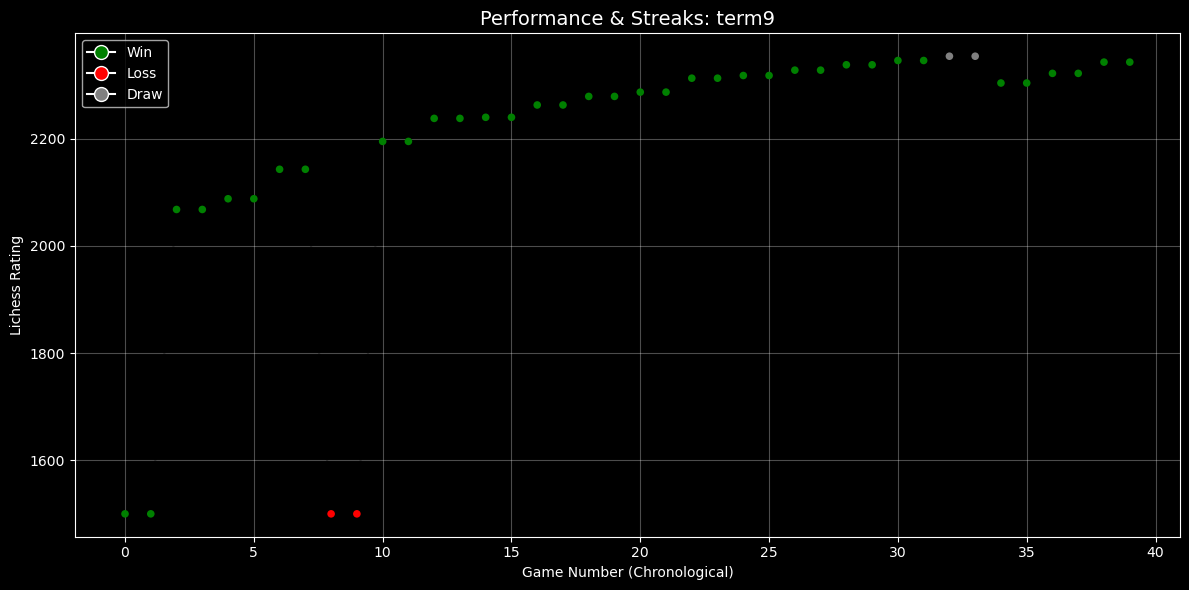

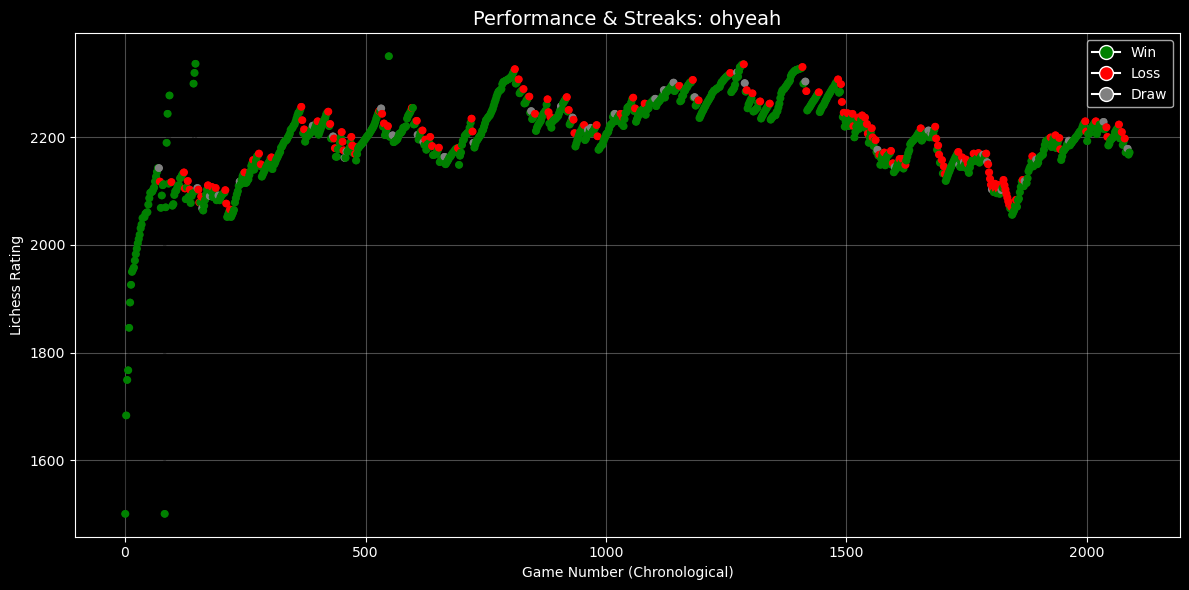

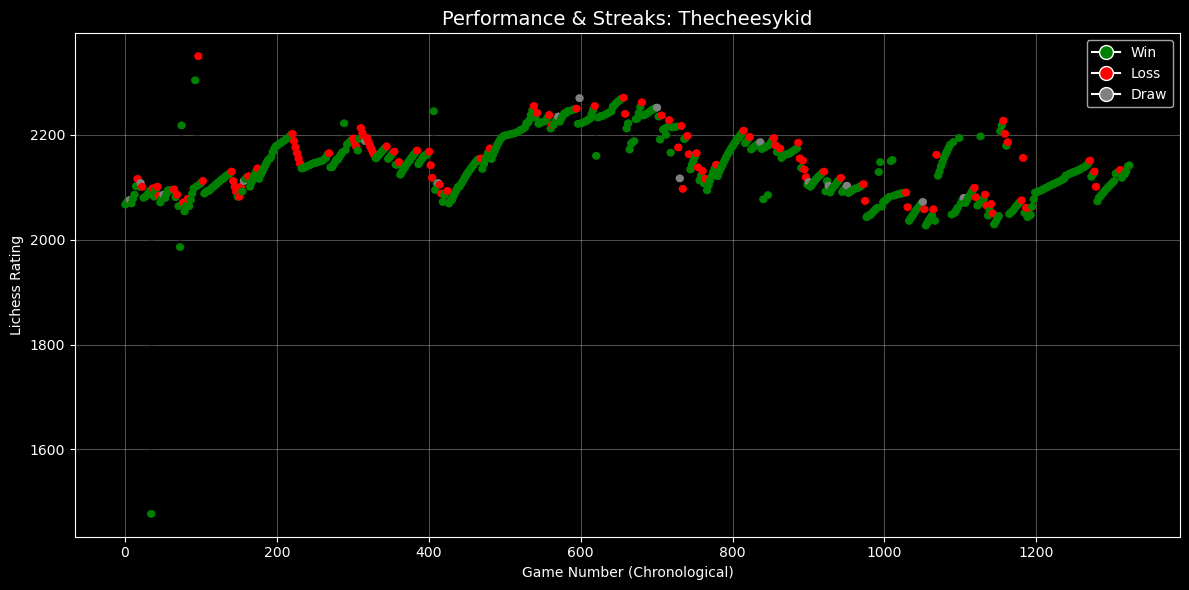

In [14]:

df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')

# 2. Identify Top 5 (Re-calculating to stay consistent)
all_stats = pd.concat([
    df[['White', 'WhiteElo']].rename(columns={'White':'Player', 'WhiteElo':'Elo'}),
    df[['Black', 'BlackElo']].rename(columns={'Black':'Player', 'BlackElo':'Elo'})
])
top_10_names = all_stats.groupby('Player')['Elo'].max().sort_values(ascending=False).head(10).index.tolist()

# 3. Plotting loop
for player in top_10_names:
    # Filter and sort games for this player
    p_games = df[(df['White'] == player) | (df['Black'] == player)].copy()
    p_games['DateTime'] = pd.to_datetime(p_games['UTCDate'] + ' ' + p_games['UTCTime'].fillna('00:00:00'))
    p_games = p_games.sort_values('DateTime')

    # Get the player's rating at the time of each game
    p_games['CurrentElo'] = p_games.apply(lambda r: r['WhiteElo'] if r['White'] == player else r['BlackElo'], axis=1)
    
    # Determine result color for markers
    def get_color(row):
        if row['Result'] == '1/2-1/2': return 'gray'  # Draw
        if (row['White'] == player and row['Result'] == '1-0') or \
           (row['Black'] == player and row['Result'] == '0-1'):
            return 'green'  # Win
        return 'red'  # Loss

    p_games['MarkerColor'] = p_games.apply(get_color, axis=1)

    # Create the Plot
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(p_games)), p_games['CurrentElo'], color='black', alpha=0.3, label='Rating Trend')
    
    # Scatter plot for the "Streaks"
    plt.scatter(range(len(p_games)), p_games['CurrentElo'], 
                c=p_games['MarkerColor'], s=30, edgecolors='none', zorder=3)

    plt.title(f"Performance & Streaks: {player}", fontsize=14)
    plt.xlabel("Game Number (Chronological)")
    plt.ylabel("Lichess Rating")
    plt.grid(True, alpha=0.3)
    
    # Custom Legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Win', markerfacecolor='green', markersize=10),
                       Line2D([0], [0], marker='o', color='w', label='Loss', markerfacecolor='red', markersize=10),
                       Line2D([0], [0], marker='o', color='w', label='Draw', markerfacecolor='gray', markersize=10)]
    plt.legend(handles=legend_elements, loc='best')

    plt.tight_layout()
    plt.savefig(f"D:\Chess\{player}_streak_plot.png")
    plt.show()

Intermediate players 

C:\Users\salma\AppData\Local\Temp\ipykernel_20368\1980940268.py:2: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\Chess\master_chess_data_2013_full.csv")


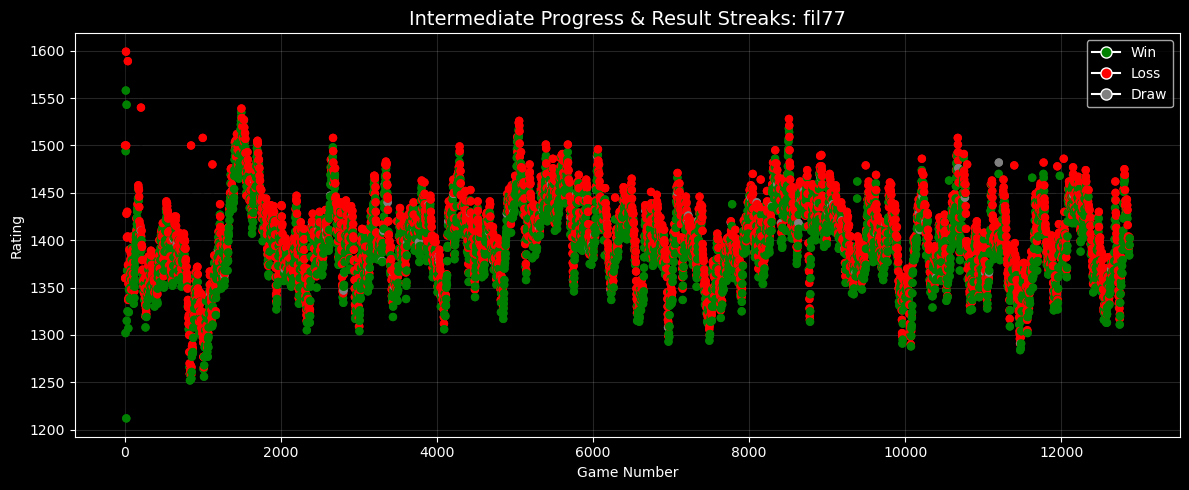

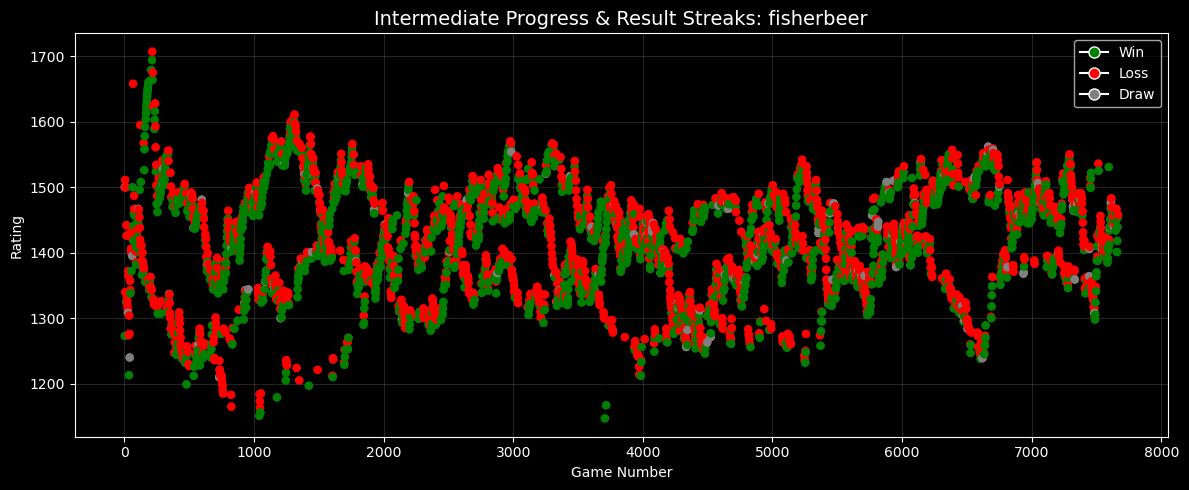

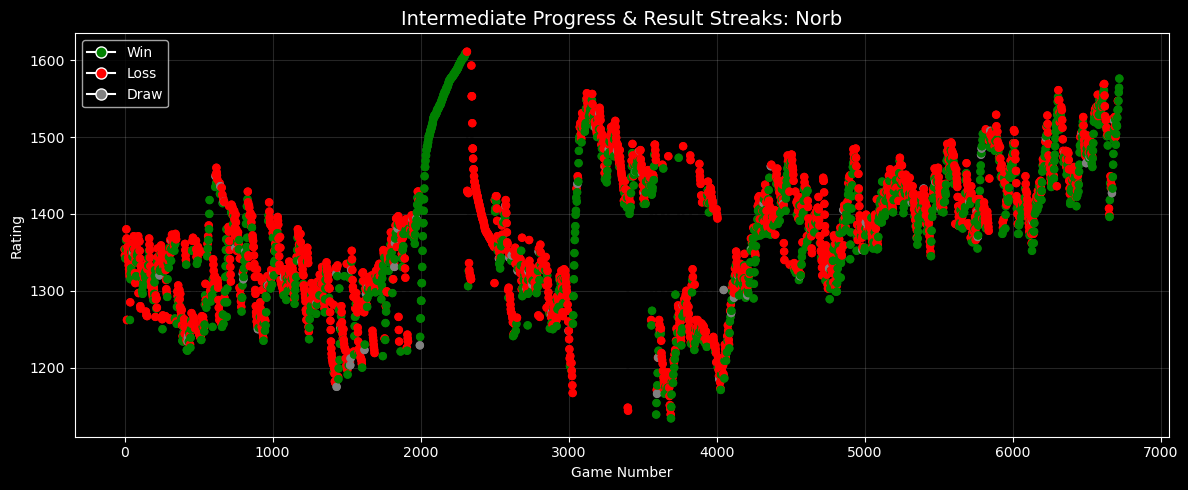

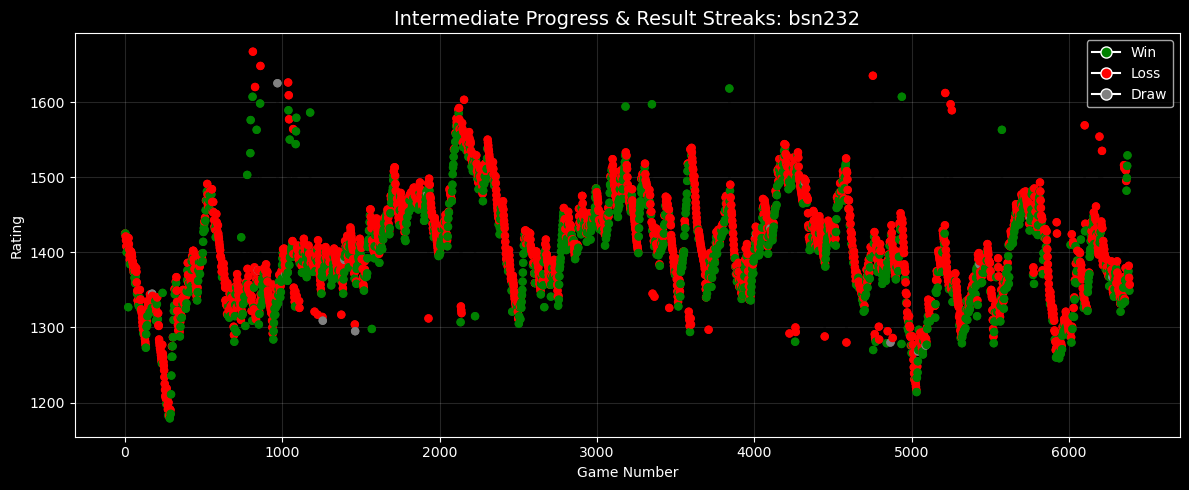

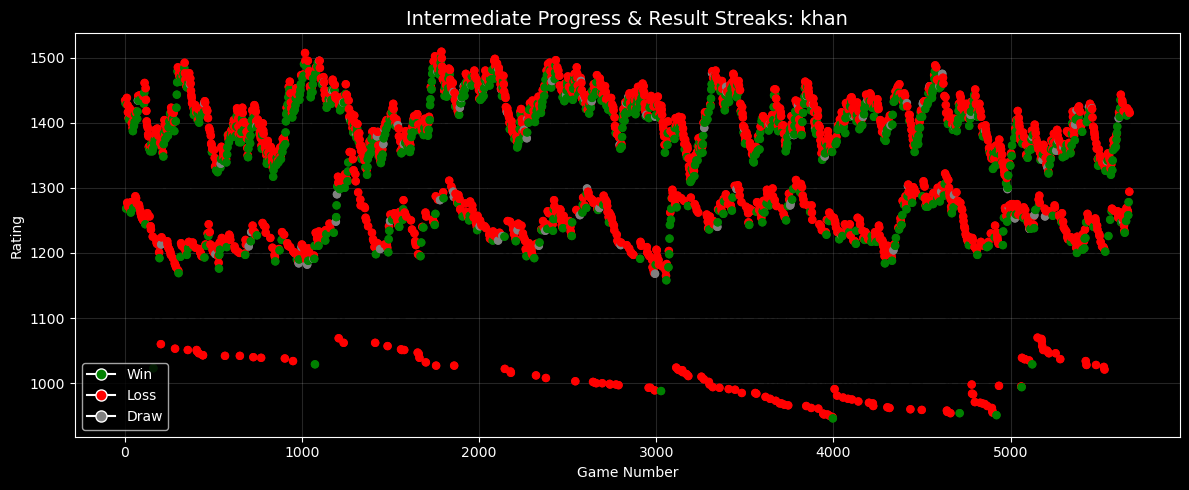

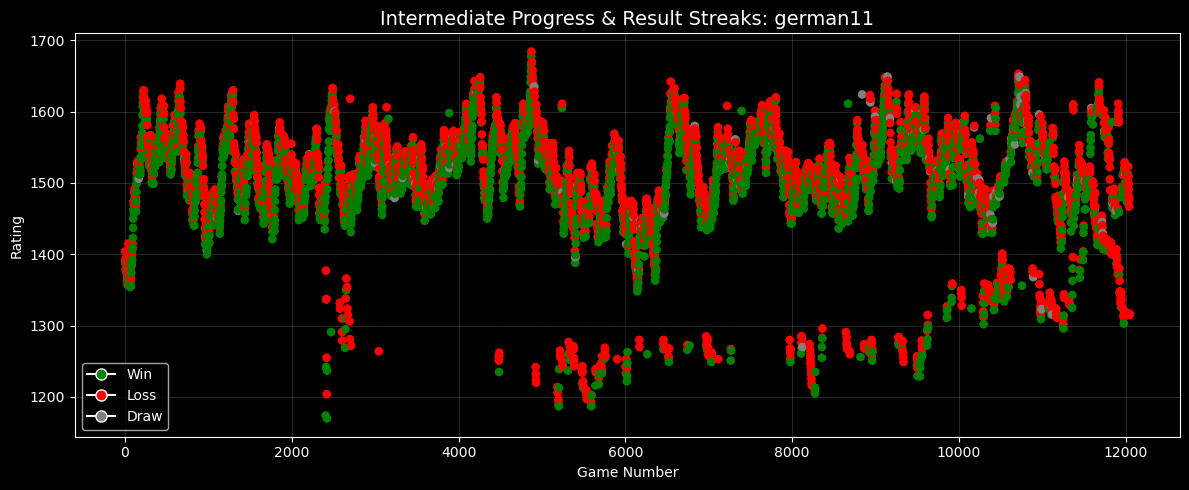

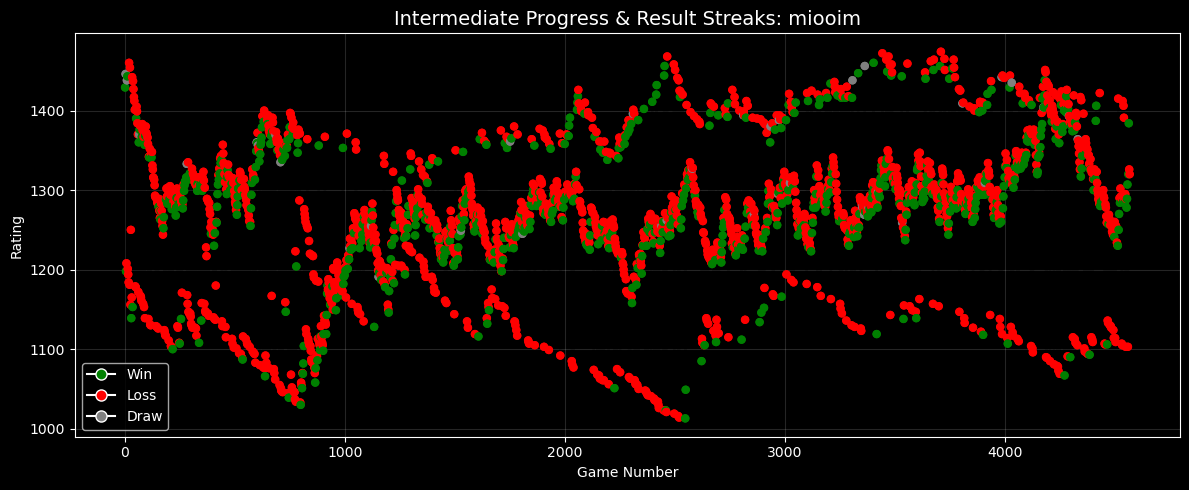

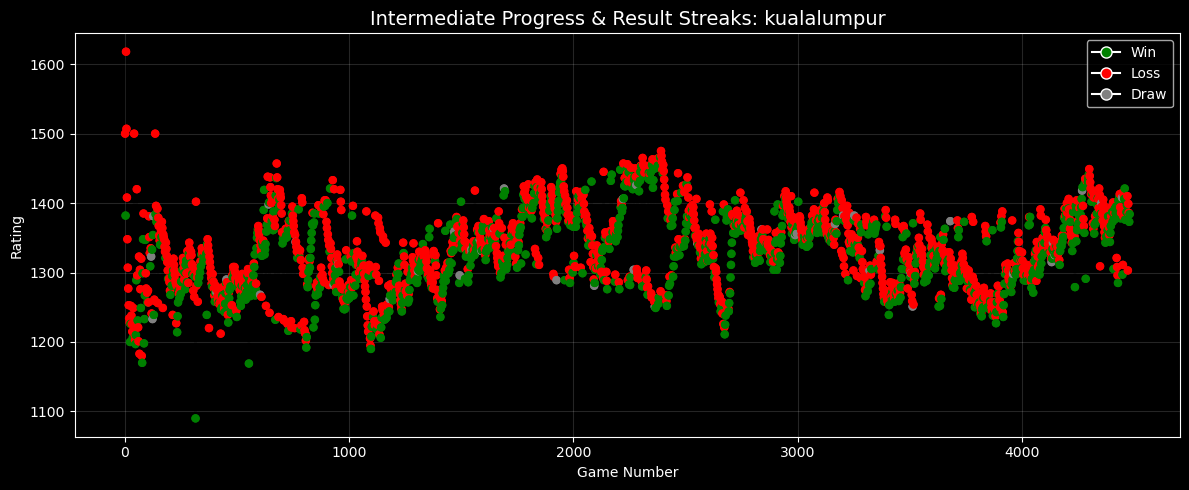

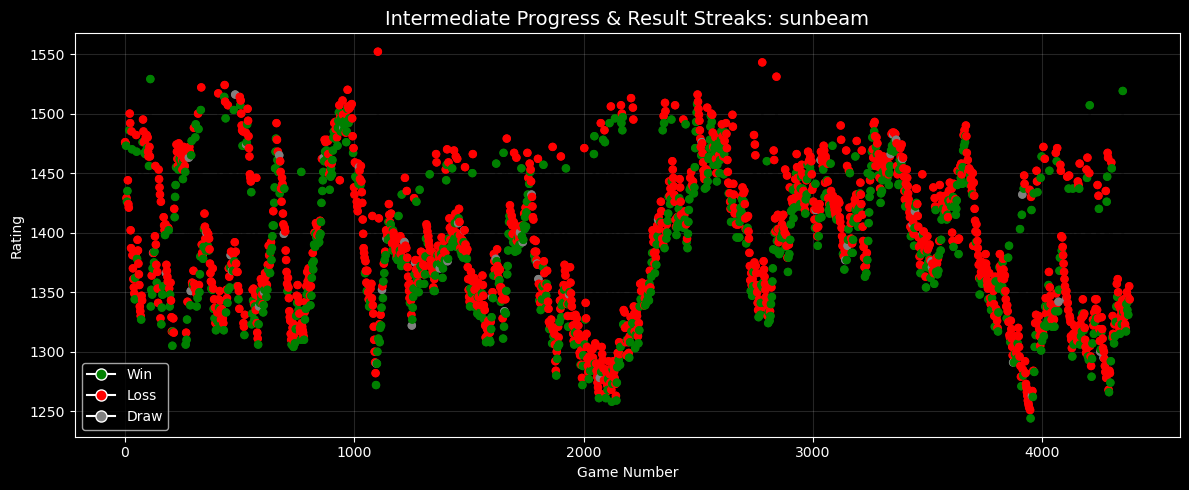

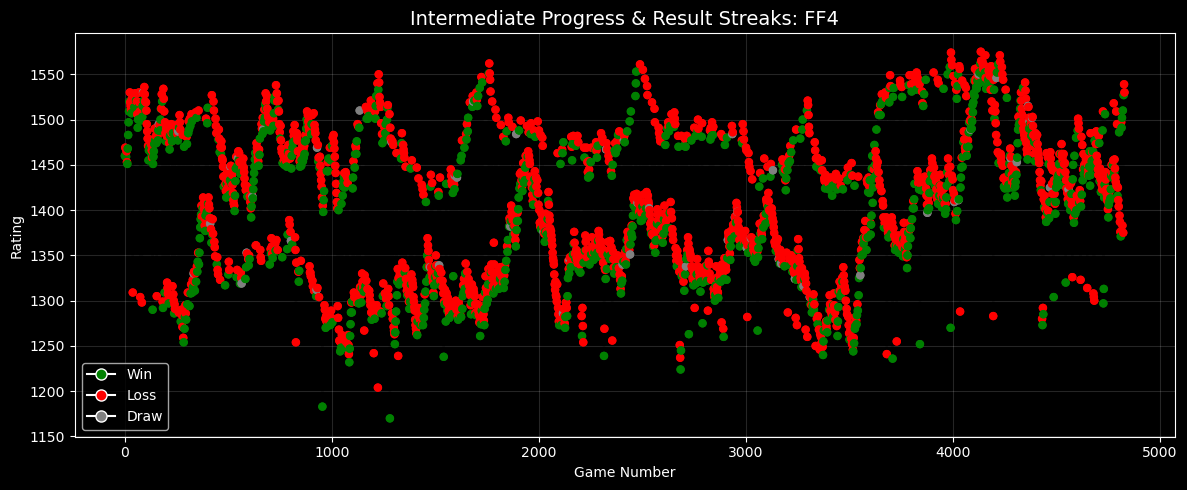

In [15]:
# 1. Load and Fix Elo Columns
df = pd.read_csv(r"D:\Chess\master_chess_data_2013_full.csv")
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')

# 2. Find the 10 Most Active Intermediate Players (1000-1500)
white_stats = df[['White', 'WhiteElo']].rename(columns={'White':'Player', 'WhiteElo':'Elo'})
black_stats = df[['Black', 'BlackElo']].rename(columns={'Black':'Player', 'BlackElo':'Elo'})
all_players = pd.concat([white_stats, black_stats])

intermediate_pool = all_players[(all_players['Elo'] >= 1000) & (all_players['Elo'] <= 1500)]
top_10_inter = intermediate_pool['Player'].value_counts().head(10).index.tolist()

# 3. Create the Styled Plots
for player in top_10_inter:
    p_games = df[(df['White'] == player) | (df['Black'] == player)].copy()
    p_games['DateTime'] = pd.to_datetime(p_games['UTCDate'] + ' ' + p_games['UTCTime'].fillna('00:00:00'))
    p_games = p_games.sort_values('DateTime')

    # Get rating for each game
    p_games['CurrentElo'] = p_games.apply(lambda r: r['WhiteElo'] if r['White'] == player else r['BlackElo'], axis=1)
    
    # Assign Marker Colors
    def get_marker_color(row):
        if row['Result'] == '1/2-1/2': return 'gray'
        if (row['White'] == player and row['Result'] == '1-0') or \
           (row['Black'] == player and row['Result'] == '0-1'):
            return 'green'
        return 'red'

    p_games['MarkerColor'] = p_games.apply(get_marker_color, axis=1)

    # Plotting
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(p_games)), p_games['CurrentElo'], color='black', alpha=0.2, label='Trend')
    plt.scatter(range(len(p_games)), p_games['CurrentElo'], c=p_games['MarkerColor'], s=25, zorder=3)

    # Style Adjustments
    plt.title(f"Intermediate Progress & Result Streaks: {player}", fontsize=14)
    plt.xlabel("Game Number")
    plt.ylabel("Rating")
    plt.grid(True, alpha=0.15)
    
    # Custom Advanced Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Win', markerfacecolor='green', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Loss', markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Draw', markerfacecolor='gray', markersize=8)
    ]
    plt.legend(handles=legend_elements, loc='best')
    
    plt.tight_layout()
    plt.savefig(f"D:\Chess\Styled_Inter_{player}.png")
    plt.show()

In [16]:
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')

# 2. Identify the 10 Most Active Beginners (500-900)
white_side = df[['White', 'WhiteElo']].rename(columns={'White':'Player', 'WhiteElo':'Elo'})
black_side = df[['Black', 'BlackElo']].rename(columns={'Black':'Player', 'BlackElo':'Elo'})
all_players = pd.concat([white_side, black_side])

# Filter for the 500-900 range
beginner_pool = all_players[(all_players['Elo'] >= 500) & (all_players['Elo'] <= 900)]
top_10_beginners = beginner_pool['Player'].value_counts().head(10).index.tolist()

# 3. Create the Styled Matplotlib Plots
for player in top_10_beginners:
    p_games = df[(df['White'] == player) | (df['Black'] == player)].copy()
    p_games['DateTime'] = pd.to_datetime(p_games['UTCDate'] + ' ' + p_games['UTCTime'].fillna('00:00:00'))
    p_games = p_games.sort_values('DateTime').reset_index()

    # Get the player's rating for each game
    p_games['CurrentElo'] = p_games.apply(lambda r: r['WhiteElo'] if r['White'] == player else r['BlackElo'], axis=1)
    
    # Assign Marker Colors (Win: Green, Loss: Red, Draw: Gray)
    def get_color(row):
        if row['Result'] == '1/2-1/2': return 'gray'
        if (row['White'] == player and row['Result'] == '1-0') or \
           (row['Black'] == player and row['Result'] == '0-1'):
            return 'green'
        return 'red'

    p_games['MarkerColor'] = p_games.apply(get_color, axis=1)

    # Plotting
    plt.figure(figsize=(14, 6))
    
    # Plot the rating trend line
    plt.plot(p_games.index, p_games['CurrentElo'], color='black', alpha=0.3, linewidth=1.5, label='Rating')
    
    # Plot the result markers
    plt.scatter(p_games.index, p_games['CurrentElo'], c=p_games['MarkerColor'], s=40, zorder=3, edgecolors='white', linewidths=0.5)

    # Style Adjustments
    plt.title(f"Beginner Performance Journey: {player} (Elo 500-900)", fontsize=14, fontweight='bold')
    plt.xlabel("Game Number (Sequential)", fontsize=12)
    plt.ylabel("Rating", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Custom Chess Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Win', markerfacecolor='green', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Loss', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Draw', markerfacecolor='gray', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='upper left', frameon=True)

    plt.tight_layout()
    plt.savefig(f"D:\Chess\Beginner_{player}_Streak.png")
    plt.show()

Geometric distribution analysis 

In [17]:
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_csv(r"D:\Chess\master_chess_data_2013_full.csv")
df['WhiteElo'] = pd.to_numeric(df['WhiteElo'], errors='coerce')
df['BlackElo'] = pd.to_numeric(df['BlackElo'], errors='coerce')

def run_geometric_analysis(player_list, group_name):
    print(f"\n--- {group_name} Analysis ---")
    results = []
    
    for player in player_list:
        p_games = df[(df['White'] == player) | (df['Black'] == player)].copy()
        
        # Calculate Win Rate (p)
        wins = len(p_games[((p_games['White'] == player) & (p_games['Result'] == '1-0')) | 
                           ((p_games['Black'] == player) & (p_games['Result'] == '0-1'))])
        p = wins / len(p_games) if len(p_games) > 0 else 0
        
        # Find Actual Longest Win Streak
        p_games['IsWin'] = ((p_games['White'] == player) & (p_games['Result'] == '1-0')) | \
                           ((p_games['Black'] == player) & (p_games['Result'] == '0-1'))
        
        # Logic to count consecutive True values
        win_groups = p_games['IsWin'].ne(p_games['IsWin'].shift()).cumsum()
        max_streak = p_games[p_games['IsWin']].groupby(win_groups).size().max() if p_games['IsWin'].any() else 0
        
        # Geometric Metrics
        expected_avg_streak = p / (1 - p) if p < 1 else np.inf
        prob_of_max_streak = (p ** max_streak) # Likelihood of this specific streak length
        
        results.append({
            'Player': player,
            'Win Rate': f"{p:.1%}",
            'Exp. Avg Streak': f"{expected_avg_streak:.2f}",
            'Actual Max Streak': max_streak,
            'P-Value (Luck)': f"{prob_of_max_streak:.5f}"
        })
    
    print(pd.DataFrame(results))

# 2. Define Groups (Re-using your previous logic for Top 5, Inter, and Beginner)
# [Insert your logic for top_5_names, top_10_inter, and top_10_beginners here]

run_geometric_analysis(top_10_names, "ADVANCED")
run_geometric_analysis(top_10_inter, "INTERMEDIATE")
run_geometric_analysis(top_10_beginners, "BEGINNERS")

C:\Users\salma\AppData\Local\Temp\ipykernel_20368\924356957.py:5: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\Chess\master_chess_data_2013_full.csv")



--- ADVANCED Analysis ---
         Player Win Rate Exp. Avg Streak  Actual Max Streak P-Value (Luck)
0        stoker    42.0%            0.72                 21        0.00000
1       Gallini    85.9%            6.09                 25        0.02236
2   TeKakeIsaly    75.4%            3.06                 12        0.03362
3  brahmsguitar    44.4%            0.80                  2        0.19753
4        inhume    78.8%            3.71                 37        0.00015
5         bst01    80.9%            4.24                 54        0.00001
6       TheKing    93.3%           14.00                 14        0.38064
7         term9    90.0%            9.00                 11        0.31381
8        ohyeah    81.2%            4.33                 42        0.00016
9  Thecheesykid    81.4%            4.38                 39        0.00033

--- INTERMEDIATE Analysis ---
        Player Win Rate Exp. Avg Streak  Actual Max Streak P-Value (Luck)
0        fil77    49.5%            0.98    